# SRGAN: Super-Resolution для лиц на датасете LFW (Финальный проект)

**Дисциплина:** Generative Adversarial Networks (GANs)
**Студент:** Жалмуханбетов Д. Н.
**Тип проекта:** Super Resolution GAN

Ноутбук соответствует требованиям финального проекта:
1. Generator + Discriminator + adversarial training
2. Использование открытого датасета (LFW)
3. Экспериментальная часть: настройка гиперпараметров, сравнение эпох, анализ результатов
4. Визуализация: loss-функции, PSNR/SSIM, прогрессия генерации, сравнение real/fake, Bicubic vs SRGAN
5. Стабилизация обучения: BatchNorm, Dropout, Label Smoothing, двухфазное обучение, VGG19 Perceptual Loss
6. Метрики: PSNR, SSIM на полном test-сете
7. Сохранение чекпоинтов, результатов генерации, графиков


## 0. Импорты, сиды и устройство

In [ ]:
# === Импорты ===
import os
import shutil
import random
import json
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torchvision import datasets, transforms, models
from torchvision.utils import make_grid, save_image
from PIL import Image
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as calculate_psnr
from skimage.metrics import structural_similarity as calculate_ssim
from sklearn.datasets import fetch_lfw_people

# === Воспроизводимость ===
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# === Устройство ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Device: cuda
GPU: Tesla T4


## 0.1 Папки проекта

Все артефакты сохраняются в `/content/drive/MyDrive/SRGAN_Final/`:
- `checkpoints/` — веса по эпохам;
- `results/images/` — примеры генерации, прогрессия, сравнение Bicubic vs SRGAN;
- `results/plots/` — графики loss и метрик;
- `models/` — финальные модели.

In [ ]:
# Подключение Google Drive
try:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_DIR = Path('/content/drive/MyDrive/SRGAN_Final')
except Exception:
    PROJECT_DIR = Path('./SRGAN_Final')
    print("Colab недоступен — сохраняем локально в", PROJECT_DIR)

CHECKPOINT_DIR = PROJECT_DIR / 'checkpoints'
RESULTS_IMG_DIR = PROJECT_DIR / 'results' / 'images'
RESULTS_PLOT_DIR = PROJECT_DIR / 'results' / 'plots'
MODELS_DIR = PROJECT_DIR / 'models'
PROGRESS_DIR = PROJECT_DIR / 'results' / 'progression'

for d in (CHECKPOINT_DIR, RESULTS_IMG_DIR, RESULTS_PLOT_DIR, MODELS_DIR, PROGRESS_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("Проектные папки готовы:", PROJECT_DIR)


Mounted at /content/drive
Проектные папки готовы: /content/drive/MyDrive/SRGAN_Final


## 1. Датасет: Labeled Faces in the Wild (LFW)

- **Размер:** 13 233 цветных RGB-изображения, 5 749 людей.
- **Источник:** `sklearn.datasets.fetch_lfw_people` (LFW-deepfunneled).
- **Разделение:** 80% train / 20% test (фиксированное через `generator=torch.Generator().manual_seed(SEED)`).
- **HR:** 128×128, нормализация в `[-1, 1]` (под `tanh` генератора).
- **LR:** 32×32, бикубическая интерполяция, диапазон `[0, 1]`.
- **Коэффициент масштабирования:** ×4.

In [ ]:
# === Загрузка LFW ===
print("Загрузка LFW через scikit-learn (зеркала)...")
_ = fetch_lfw_people(color=True)

source_dir = os.path.expanduser('~/scikit_learn_data/lfw_home/lfw_funneled')
dest_dir = './lfw-deepfunneled'
if not os.path.exists(dest_dir) and os.path.exists(source_dir):
    shutil.copytree(source_dir, dest_dir)
print("Датасет готов в", dest_dir)


Загрузка LFW через scikit-learn (зеркала)...
Датасет готов в ./lfw-deepfunneled


In [ ]:
class LFW_SR_Dataset(Dataset):
    # Парный датасет LR/HR для задачи Super-Resolution
    def __init__(self, root_dir, scale_factor=4, hr_size=128):
        self.dataset = datasets.ImageFolder(root=root_dir)
        self.hr_size = hr_size
        self.lr_size = hr_size // scale_factor

        self.hr_transform = transforms.Compose([
            transforms.CenterCrop(150),
            transforms.Resize((hr_size, hr_size), Image.BICUBIC),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),  # -> [-1, 1]
        ])
        self.lr_transform = transforms.Compose([
            transforms.CenterCrop(150),
            transforms.Resize((self.lr_size, self.lr_size), Image.BICUBIC),
            transforms.ToTensor(),  # -> [0, 1]
        ])

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, _ = self.dataset[idx]
        return self.lr_transform(img), self.hr_transform(img)


HR_SIZE = 128
SCALE = 4
BATCH_SIZE = 16

full_dataset = LFW_SR_Dataset('./lfw-deepfunneled', scale_factor=SCALE, hr_size=HR_SIZE)
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size

gen_split = torch.Generator().manual_seed(SEED)
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size], generator=gen_split)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Фиксированный сабсет test для визуализации прогрессии (одни и те же 8 лиц на каждой эпохе)
FIXED_VIS_INDICES = list(range(8))
fixed_vis_subset = Subset(test_dataset, FIXED_VIS_INDICES)
fixed_lr = torch.stack([fixed_vis_subset[i][0] for i in range(len(fixed_vis_subset))]).to(device)
fixed_hr = torch.stack([fixed_vis_subset[i][1] for i in range(len(fixed_vis_subset))]).to(device)

print(f"Train: {len(train_dataset)} | Test: {len(test_dataset)} | LR: {full_dataset[0][0].shape} | HR: {full_dataset[0][1].shape}")


Train: 10586 | Test: 2647 | LR: torch.Size([3, 32, 32]) | HR: torch.Size([3, 128, 128])


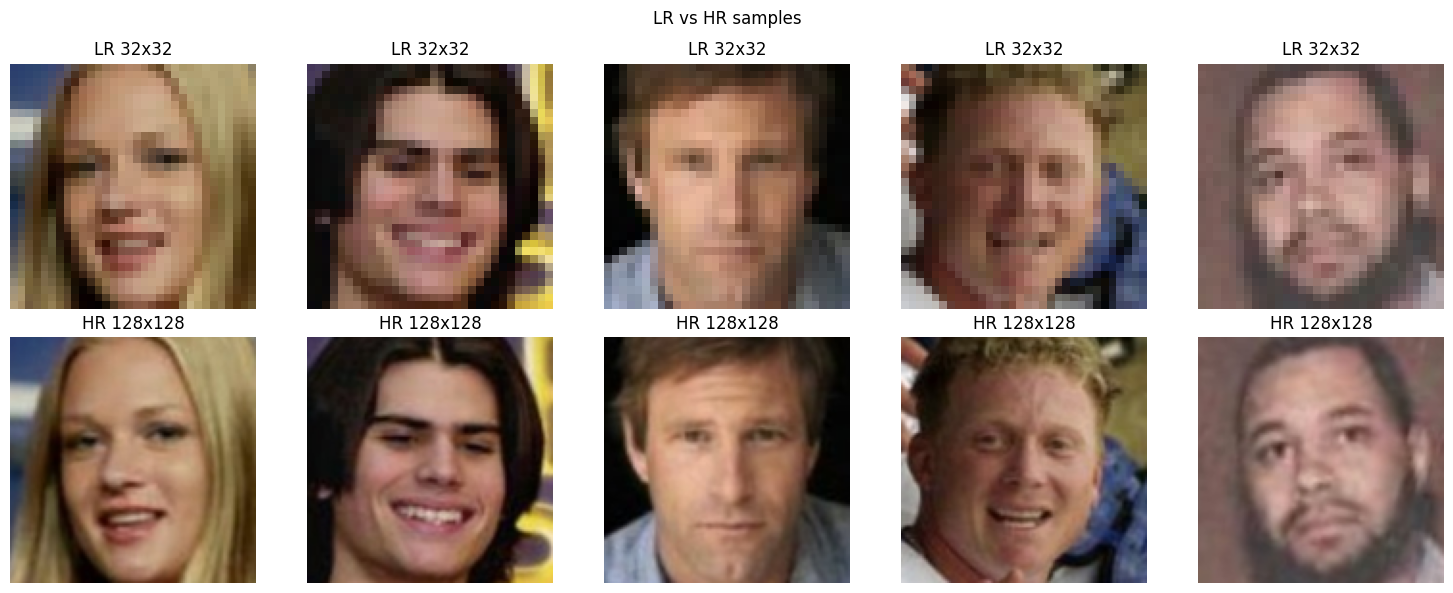

Сохранено: /content/drive/MyDrive/SRGAN_Final/results/images/dataset_samples.png


In [ ]:
# === Демонстрация LR/HR пар ===
def show_pairs(dataset, n=5, title="LR vs HR samples"):
    fig, axes = plt.subplots(2, n, figsize=(3*n, 6))
    for i in range(n):
        lr, hr = dataset[i]
        lr_img = lr.permute(1, 2, 0).cpu().numpy()
        hr_img = (hr.permute(1, 2, 0).cpu().numpy() * 0.5) + 0.5
        axes[0, i].imshow(np.clip(lr_img, 0, 1)); axes[0, i].set_title(f"LR {lr.shape[1]}x{lr.shape[2]}"); axes[0, i].axis('off')
        axes[1, i].imshow(np.clip(hr_img, 0, 1)); axes[1, i].set_title(f"HR {hr.shape[1]}x{hr.shape[2]}"); axes[1, i].axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    out_path = RESULTS_IMG_DIR / 'dataset_samples.png'
    plt.savefig(out_path, dpi=120, bbox_inches='tight')
    plt.show()
    print("Сохранено:", out_path)

show_pairs(full_dataset, n=5)


## 2. Архитектура моделей

### Generator (SRResNet-style)
- Начальная свёртка `9×9, 64 ch` + PReLU;
- **5 Residual Blocks** (Conv3×3 → BN → PReLU → Conv3×3 → BN, skip-connection);
- Свёртка `3×3` + BN, skip от initial;
- **2 × Sub-Pixel Conv (PixelShuffle)** → апскейлинг ×4;
- Финальная свёртка `9×9` → `tanh`.

### Discriminator (VGG-style + Dropout)
- Каскад из 7 свёрток `3×3` с увеличением каналов 64 → 512;
- BatchNorm + LeakyReLU(0.2) + **Dropout(0.3)** во внутренних блоках;
- AdaptiveAvgPool → `1×1` свёртки → Sigmoid.

### VGG19 Feature Extractor
- Слой `relu5_4` (стандарт для SRGAN);
- Заморожен (`requires_grad=False`);
- Принимает изображения, нормализованные ImageNet-mean/std.

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv1 = nn.Conv2d(ch, ch, 3, padding=1)
        self.bn1   = nn.BatchNorm2d(ch)
        self.prelu = nn.PReLU()
        self.conv2 = nn.Conv2d(ch, ch, 3, padding=1)
        self.bn2   = nn.BatchNorm2d(ch)

    def forward(self, x):
        r = self.prelu(self.bn1(self.conv1(x)))
        r = self.bn2(self.conv2(r))
        return x + r


class Generator(nn.Module):
    def __init__(self, n_res_blocks=5):
        super().__init__()
        self.initial = nn.Sequential(
            nn.Conv2d(3, 64, 9, padding=4),
            nn.PReLU(),
        )
        self.res_blocks = nn.Sequential(*[ResidualBlock(64) for _ in range(n_res_blocks)])
        self.mid = nn.Sequential(
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
        )
        # 2 × PixelShuffle = ×4 апскейл
        self.upsample = nn.Sequential(
            nn.Conv2d(64, 256, 3, padding=1),
            nn.PixelShuffle(2),
            nn.PReLU(),
            nn.Conv2d(64, 256, 3, padding=1),
            nn.PixelShuffle(2),
            nn.PReLU(),
        )
        self.final = nn.Conv2d(64, 3, 9, padding=4)

    def forward(self, x):
        ini = self.initial(x)
        r = self.mid(self.res_blocks(ini))
        out = self.upsample(ini + r)
        return torch.tanh(self.final(out))


class Discriminator(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        def block(in_c, out_c, stride):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, stride=stride, padding=1),
                nn.BatchNorm2d(out_c),
                nn.LeakyReLU(0.2, inplace=True),
                nn.Dropout2d(dropout),  # регуляризация D
            )
        self.model = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            block(64, 64, 2),
            block(64, 128, 1),
            block(128, 128, 2),
            block(128, 256, 1),
            block(256, 256, 2),
            block(256, 512, 1),
            block(512, 512, 2),
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(512, 1024, 1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(dropout),
            nn.Conv2d(1024, 1, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.model(x).view(x.size(0), -1)


class VGGFeatureExtractor(nn.Module):
    # VGG19 до layer 35 = relu5_4 (как в оригинальной SRGAN)
    def __init__(self):
        super().__init__()
        vgg = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1)
        self.features = nn.Sequential(*list(vgg.features.children())[:36]).eval()
        for p in self.features.parameters():
            p.requires_grad = False
        self.register_buffer('mean', torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1))
        self.register_buffer('std',  torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1))

    def forward(self, x):
        # x в диапазоне [-1, 1] -> [0, 1] -> нормализация ImageNet
        x = (x + 1) / 2.0
        x = (x - self.mean) / self.std
        return self.features(x)


# Инстанцирование
generator     = Generator(n_res_blocks=5).to(device)
discriminator = Discriminator(dropout=0.3).to(device)
vgg_extractor = VGGFeatureExtractor().to(device)

n_params_g = sum(p.numel() for p in generator.parameters())
n_params_d = sum(p.numel() for p in discriminator.parameters())
print(f"Generator params:     {n_params_g:,}")
print(f"Discriminator params: {n_params_d:,}")


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:06<00:00, 95.6MB/s]


Generator params:     734,219
Discriminator params: 5,215,425


## 3. Утилиты обучения и оценки

- `evaluate_on_test` — средние PSNR/SSIM на всём `test_loader`;
- `save_checkpoint` / `load_checkpoint` — полный state (G, D, optimizers, эпоха);
- `save_progression_grid` — генерация на фиксированном `fixed_lr` и сохранение `epoch_XX.png`.

In [ ]:
def tensor_to_img(t):
    # Тензор [-1, 1] (C,H,W) -> numpy [0, 1] (H,W,C)
    img = (t.detach().cpu() + 1) / 2.0
    return np.clip(img.permute(1, 2, 0).numpy(), 0, 1)


@torch.no_grad()
def evaluate_on_test(gen, loader, max_batches=None):
    # Средние PSNR / SSIM на test-сете
    gen.eval()
    psnr_vals, ssim_vals = [], []
    for bi, (lr, hr) in enumerate(loader):
        if max_batches is not None and bi >= max_batches:
            break
        lr = lr.to(device)
        gen_hr = gen(lr).cpu()
        hr = hr.cpu()
        for i in range(gen_hr.size(0)):
            g = tensor_to_img(gen_hr[i])
            h = tensor_to_img(hr[i])
            psnr_vals.append(calculate_psnr(h, g, data_range=1.0))
            ssim_vals.append(calculate_ssim(h, g, data_range=1.0, channel_axis=-1))
    gen.train()
    return float(np.mean(psnr_vals)), float(np.mean(ssim_vals))


def save_checkpoint(epoch, gen, disc, opt_g, opt_d, tag='srgan'):
    path = CHECKPOINT_DIR / f'{tag}_epoch_{epoch:03d}.pth'
    torch.save({
        'epoch': epoch,
        'generator_state_dict': gen.state_dict(),
        'discriminator_state_dict': disc.state_dict(),
        'g_optimizer_state_dict': opt_g.state_dict(),
        'd_optimizer_state_dict': opt_d.state_dict(),
    }, path)
    return path


@torch.no_grad()
def save_progression_grid(gen, epoch, fixed_lr, fixed_hr):
    # Сохранить grid (LR-upscaled / Generated / HR) для одних и тех же лиц на каждой эпохе
    gen.eval()
    gen_hr = gen(fixed_lr)
    gen.train()
    # Делаем LR-upscaled (nearest) для одинакового размера в сетке
    lr_up = F.interpolate(fixed_lr * 2 - 1, size=gen_hr.shape[-2:], mode='nearest')
    # Все три блока в [-1, 1] -> приводим к [0, 1] для сохранения
    rows = []
    for i in range(fixed_lr.size(0)):
        rows.append(torch.stack([
            (lr_up[i] + 1) / 2,
            (gen_hr[i] + 1) / 2,
            (fixed_hr[i] + 1) / 2,
        ]))
    grid = torch.cat(rows, dim=0)
    out_path = PROGRESS_DIR / f'epoch_{epoch:03d}.png'
    save_image(grid, out_path, nrow=3, padding=2)
    return out_path


## 4. Обучение

### Гиперпараметры
| Параметр | Значение | Комментарий |
|---|---|---|
| Optimizer | Adam | `betas=(0.9, 0.999)` для G/D на GAN-фазе |
| Learning rate | `1e-4` | Стандарт для SRGAN |
| Batch size | 16 | Под 12 GB GPU |
| Pre-train epochs | 10 | Только MSE — стабилизирует геометрию |
| GAN epochs | 40 | Полный лосс: MSE + Adv + Perceptual |
| Adversarial weight | `1e-3` | Балансировка против доминирования D |
| Perceptual weight | `6e-3` | VGG19-relu5_4, как в оригинале |
| Label smoothing | `0.9` для real | Регуляризация D |
| Dropout | 0.3 | В дискриминаторе |
| Checkpoint каждые | 10 эпох | Защита от обрыва Colab-сессии |

### Стратегия
1. **Pre-training (10 эпох):** только `MSELoss(gen_hr, hr)`. Цель — научить G корректной геометрии.
2. **GAN training (40 эпох):** полный лосс генератора:
   $$L_G = L_{MSE} + 10^{-3} \cdot L_{adv} + 6 \cdot 10^{-3} \cdot L_{perceptual}$$
   где $L_{perceptual} = \|\phi(G(LR)) - \phi(HR)\|_2^2$, $\phi$ — VGG19 relu5_4.

In [ ]:
# === Гиперпараметры ===
PRETRAIN_EPOCHS = 10
GAN_EPOCHS      = 40
LR              = 1e-4
ADV_WEIGHT      = 1e-3
PERCEPTUAL_W    = 6e-3
LABEL_SMOOTH    = 0.9
CKPT_EVERY      = 10
EVAL_MAX_BATCHES = 30  # для скорости — оценивать первые 30 батчей test'а (~480 изобр.)

criterion_bce   = nn.BCELoss()
criterion_pixel = nn.MSELoss()
criterion_vgg   = nn.MSELoss()

optimizer_G = optim.Adam(generator.parameters(),     lr=LR, betas=(0.9, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=LR, betas=(0.9, 0.999))

# История метрик и лоссов (по эпохам)
history = {
    'epoch': [],
    'g_loss': [], 'd_loss': [],
    'pixel_loss': [], 'adv_loss': [], 'perc_loss': [],
    'test_psnr': [], 'test_ssim': [],
    'phase': [],  # 'pretrain' | 'gan'
}
print("Гиперпараметры готовы. Начинаем обучение.")


Гиперпараметры готовы. Начинаем обучение.


In [ ]:
# ==========================================
# ЭТАП 1: Pre-training Generator (MSE only)
# ==========================================
print("="*60)
print("ЭТАП 1: Pre-training Generator (только MSE)")
print("="*60)
generator.train()

for epoch in range(1, PRETRAIN_EPOCHS + 1):
    epoch_pixel = []
    for i, (lr, hr) in enumerate(train_loader):
        lr, hr = lr.to(device), hr.to(device)
        optimizer_G.zero_grad()
        gen_hr = generator(lr)
        loss = criterion_pixel(gen_hr, hr)
        loss.backward()
        optimizer_G.step()
        epoch_pixel.append(loss.item())
        if i % 200 == 0:
            print(f"  [Pretrain {epoch}/{PRETRAIN_EPOCHS}] batch {i}/{len(train_loader)} | MSE={loss.item():.4f}")

    # Метрики и снимок прогрессии после каждой эпохи
    psnr, ssim_v = evaluate_on_test(generator, test_loader, max_batches=EVAL_MAX_BATCHES)
    save_progression_grid(generator, epoch, fixed_lr, fixed_hr)
    history['epoch'].append(epoch)
    history['g_loss'].append(float(np.mean(epoch_pixel)))
    history['d_loss'].append(0.0)
    history['pixel_loss'].append(float(np.mean(epoch_pixel)))
    history['adv_loss'].append(0.0)
    history['perc_loss'].append(0.0)
    history['test_psnr'].append(psnr)
    history['test_ssim'].append(ssim_v)
    history['phase'].append('pretrain')
    print(f"  >>> Epoch {epoch} done | MSE={np.mean(epoch_pixel):.4f} | "
          f"Test PSNR={psnr:.2f} dB | SSIM={ssim_v:.4f}")

    if epoch % CKPT_EVERY == 0:
        p = save_checkpoint(epoch, generator, discriminator, optimizer_G, optimizer_D, tag='pretrain')
        print(f"  чекпоинт: {p}")

print("Pre-training завершён.")


ЭТАП 1: Pre-training Generator (только MSE)
  [Pretrain 1/10] batch 0/662 | MSE=0.2610
  [Pretrain 1/10] batch 200/662 | MSE=0.0161
  [Pretrain 1/10] batch 400/662 | MSE=0.0151
  [Pretrain 1/10] batch 600/662 | MSE=0.0113
  >>> Epoch 1 done | MSE=0.0186 | Test PSNR=24.77 dB | SSIM=0.8093
  [Pretrain 2/10] batch 0/662 | MSE=0.0165
  [Pretrain 2/10] batch 200/662 | MSE=0.0070
  [Pretrain 2/10] batch 400/662 | MSE=0.0064
  [Pretrain 2/10] batch 600/662 | MSE=0.0084
  >>> Epoch 2 done | MSE=0.0082 | Test PSNR=26.70 dB | SSIM=0.8458
  [Pretrain 3/10] batch 0/662 | MSE=0.0067
  [Pretrain 3/10] batch 200/662 | MSE=0.0089
  [Pretrain 3/10] batch 400/662 | MSE=0.0059
  [Pretrain 3/10] batch 600/662 | MSE=0.0057
  >>> Epoch 3 done | MSE=0.0065 | Test PSNR=29.32 dB | SSIM=0.8657
  [Pretrain 4/10] batch 0/662 | MSE=0.0058
  [Pretrain 4/10] batch 200/662 | MSE=0.0052
  [Pretrain 4/10] batch 400/662 | MSE=0.0050
  [Pretrain 4/10] batch 600/662 | MSE=0.0062
  >>> Epoch 4 done | MSE=0.0058 | Test PSNR

In [ ]:
# ==========================================
# ЭТАП 2: GAN training (MSE + Adversarial + Perceptual)
# ==========================================
print("="*60)
print("ЭТАП 2: Adversarial training (MSE + Adv + Perceptual)")
print("="*60)
generator.train()
discriminator.train()

START = PRETRAIN_EPOCHS + 1
END   = PRETRAIN_EPOCHS + GAN_EPOCHS

for epoch in range(START, END + 1):
    ep_g, ep_d, ep_px, ep_adv, ep_perc = [], [], [], [], []

    for i, (lr, hr) in enumerate(train_loader):
        lr, hr = lr.to(device), hr.to(device)
        bs = lr.size(0)
        valid = torch.full((bs, 1), LABEL_SMOOTH, device=device)
        fake  = torch.zeros((bs, 1), device=device)
        ones  = torch.ones((bs, 1), device=device)

        # --- Train Discriminator ---
        optimizer_D.zero_grad()
        gen_hr = generator(lr)
        d_real = discriminator(hr)
        d_fake = discriminator(gen_hr.detach())
        d_loss = 0.5 * (criterion_bce(d_real, valid) + criterion_bce(d_fake, fake))
        d_loss.backward()
        optimizer_D.step()

        # --- Train Generator ---
        optimizer_G.zero_grad()
        gen_hr = generator(lr)
        pixel_loss = criterion_pixel(gen_hr, hr)
        adv_loss   = criterion_bce(discriminator(gen_hr), ones)
        # Perceptual loss на VGG19 (relu5_4)
        with torch.no_grad():
            real_feat = vgg_extractor(hr)
        fake_feat = vgg_extractor(gen_hr)
        perc_loss = criterion_vgg(fake_feat, real_feat)

        g_loss = pixel_loss + ADV_WEIGHT * adv_loss + PERCEPTUAL_W * perc_loss
        g_loss.backward()
        optimizer_G.step()

        ep_g.append(g_loss.item())
        ep_d.append(d_loss.item())
        ep_px.append(pixel_loss.item())
        ep_adv.append(adv_loss.item())
        ep_perc.append(perc_loss.item())

        if i % 200 == 0:
            print(f"  [GAN {epoch}/{END}] batch {i}/{len(train_loader)} | "
                  f"D={d_loss.item():.3f} | G={g_loss.item():.3f} "
                  f"(px={pixel_loss.item():.3f}, adv={adv_loss.item():.3f}, perc={perc_loss.item():.3f})")

    psnr, ssim_v = evaluate_on_test(generator, test_loader, max_batches=EVAL_MAX_BATCHES)
    save_progression_grid(generator, epoch, fixed_lr, fixed_hr)
    history['epoch'].append(epoch)
    history['g_loss'].append(float(np.mean(ep_g)))
    history['d_loss'].append(float(np.mean(ep_d)))
    history['pixel_loss'].append(float(np.mean(ep_px)))
    history['adv_loss'].append(float(np.mean(ep_adv)))
    history['perc_loss'].append(float(np.mean(ep_perc)))
    history['test_psnr'].append(psnr)
    history['test_ssim'].append(ssim_v)
    history['phase'].append('gan')
    print(f"  >>> Epoch {epoch} done | G={np.mean(ep_g):.3f} | D={np.mean(ep_d):.3f} | "
          f"Test PSNR={psnr:.2f} | SSIM={ssim_v:.4f}")

    if epoch % CKPT_EVERY == 0:
        p = save_checkpoint(epoch, generator, discriminator, optimizer_G, optimizer_D, tag='gan')
        print(f"  чекпоинт: {p}")

# Сохраняем историю
with open(PROJECT_DIR / 'training_history.json', 'w') as f:
    json.dump(history, f, indent=2)
print("GAN training завершён. История сохранена.")


ЭТАП 2: Adversarial training (MSE + Adv + Perceptual)
  [GAN 11/50] batch 0/662 | D=0.690 | G=0.006 (px=0.005, adv=0.703, perc=0.114)
  [GAN 11/50] batch 200/662 | D=0.682 | G=0.006 (px=0.005, adv=0.806, perc=0.094)
  [GAN 11/50] batch 400/662 | D=0.682 | G=0.005 (px=0.003, adv=0.808, perc=0.085)
  [GAN 11/50] batch 600/662 | D=0.680 | G=0.005 (px=0.003, adv=0.808, perc=0.101)
  >>> Epoch 11 done | G=0.005 | D=0.691 | Test PSNR=30.86 | SSIM=0.8982
  [GAN 12/50] batch 0/662 | D=0.694 | G=0.004 (px=0.003, adv=0.782, perc=0.061)
  [GAN 12/50] batch 200/662 | D=0.669 | G=0.005 (px=0.003, adv=0.761, perc=0.066)
  [GAN 12/50] batch 400/662 | D=0.662 | G=0.005 (px=0.004, adv=0.785, perc=0.096)
  [GAN 12/50] batch 600/662 | D=0.688 | G=0.005 (px=0.004, adv=0.806, perc=0.091)
  >>> Epoch 12 done | G=0.005 | D=0.690 | Test PSNR=30.36 | SSIM=0.8993
  [GAN 13/50] batch 0/662 | D=0.687 | G=0.006 (px=0.004, adv=0.829, perc=0.112)
  [GAN 13/50] batch 200/662 | D=0.691 | G=0.005 (px=0.004, adv=0.774, 

## 5. Визуализация результатов

### 5.1 Графики обучения

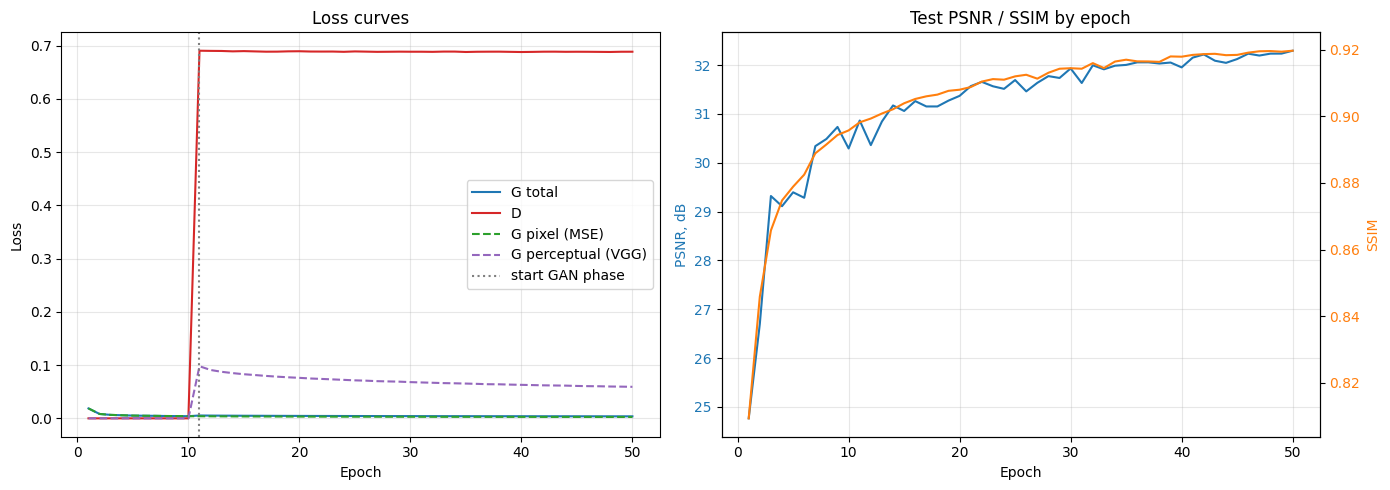

In [ ]:
# === Графики loss-функций ===
ep = history['epoch']
phase_change = next((i for i, p in enumerate(history['phase']) if p == 'gan'), len(ep))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(ep, history['g_loss'], label='G total', color='tab:blue')
axes[0].plot(ep, history['d_loss'], label='D', color='tab:red')
axes[0].plot(ep, history['pixel_loss'], label='G pixel (MSE)', color='tab:green', linestyle='--')
axes[0].plot(ep, history['perc_loss'], label='G perceptual (VGG)', color='tab:purple', linestyle='--')
if phase_change > 0 and phase_change < len(ep):
    axes[0].axvline(ep[phase_change], color='gray', linestyle=':', label='start GAN phase')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].set_title('Loss curves')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Metrics curves
ax2 = axes[1]
ax2.plot(ep, history['test_psnr'], color='tab:blue', label='PSNR (dB)')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('PSNR, dB', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')
ax2b = ax2.twinx()
ax2b.plot(ep, history['test_ssim'], color='tab:orange', label='SSIM')
ax2b.set_ylabel('SSIM', color='tab:orange')
ax2b.tick_params(axis='y', labelcolor='tab:orange')
ax2.set_title('Test PSNR / SSIM by epoch'); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_PLOT_DIR / 'training_curves.png', dpi=120, bbox_inches='tight')
plt.show()


### 5.2 Сравнение эпох (прогрессия генерации)

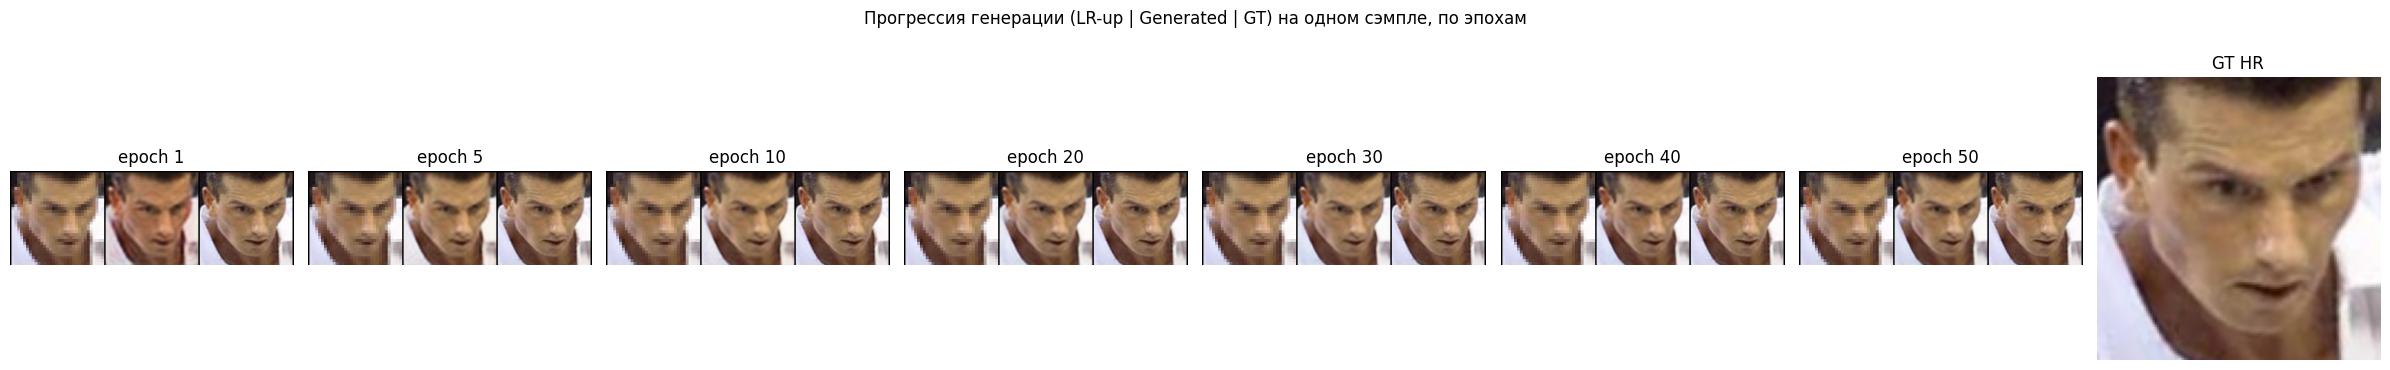

In [ ]:
# === Сетка эпох: показываем один и тот же сэмпл на разных эпохах ===
EPOCHS_TO_SHOW = [1, 5, 10, 20, 30, 40, 50]
EPOCHS_TO_SHOW = [e for e in EPOCHS_TO_SHOW if e in history['epoch']]
sample_idx = 0  # первый фиксированный сэмпл

fig, axes = plt.subplots(1, len(EPOCHS_TO_SHOW) + 1, figsize=(3 * (len(EPOCHS_TO_SHOW) + 1), 4))
for k, e in enumerate(EPOCHS_TO_SHOW):
    img_path = PROGRESS_DIR / f'epoch_{e:03d}.png'
    if img_path.exists():
        # Загружаем сохранённый grid и режем верхнюю карточку первого сэмпла
        grid = Image.open(img_path)
        # В нашем save_progression_grid строки идут sample-by-sample, по 3 в ряд
        # Для упрощения: показываем целиком сохранённую первую строку (один сэмпл = одна "тройка")
        w, h = grid.size
        n_samples = fixed_lr.size(0)
        row_h = h // n_samples
        row = grid.crop((0, sample_idx * row_h, w, (sample_idx + 1) * row_h))
        axes[k].imshow(row)
    axes[k].set_title(f'epoch {e}')
    axes[k].axis('off')

# Последний — GT HR
axes[-1].imshow(tensor_to_img(fixed_hr[sample_idx]))
axes[-1].set_title('GT HR'); axes[-1].axis('off')

plt.suptitle('Прогрессия генерации (LR-up | Generated | GT) на одном сэмпле, по эпохам')
plt.tight_layout()
plt.savefig(RESULTS_PLOT_DIR / 'epochs_progression.png', dpi=120, bbox_inches='tight')
plt.show()


### 5.3 Сравнение Real / Fake и Bicubic baseline vs SRGAN

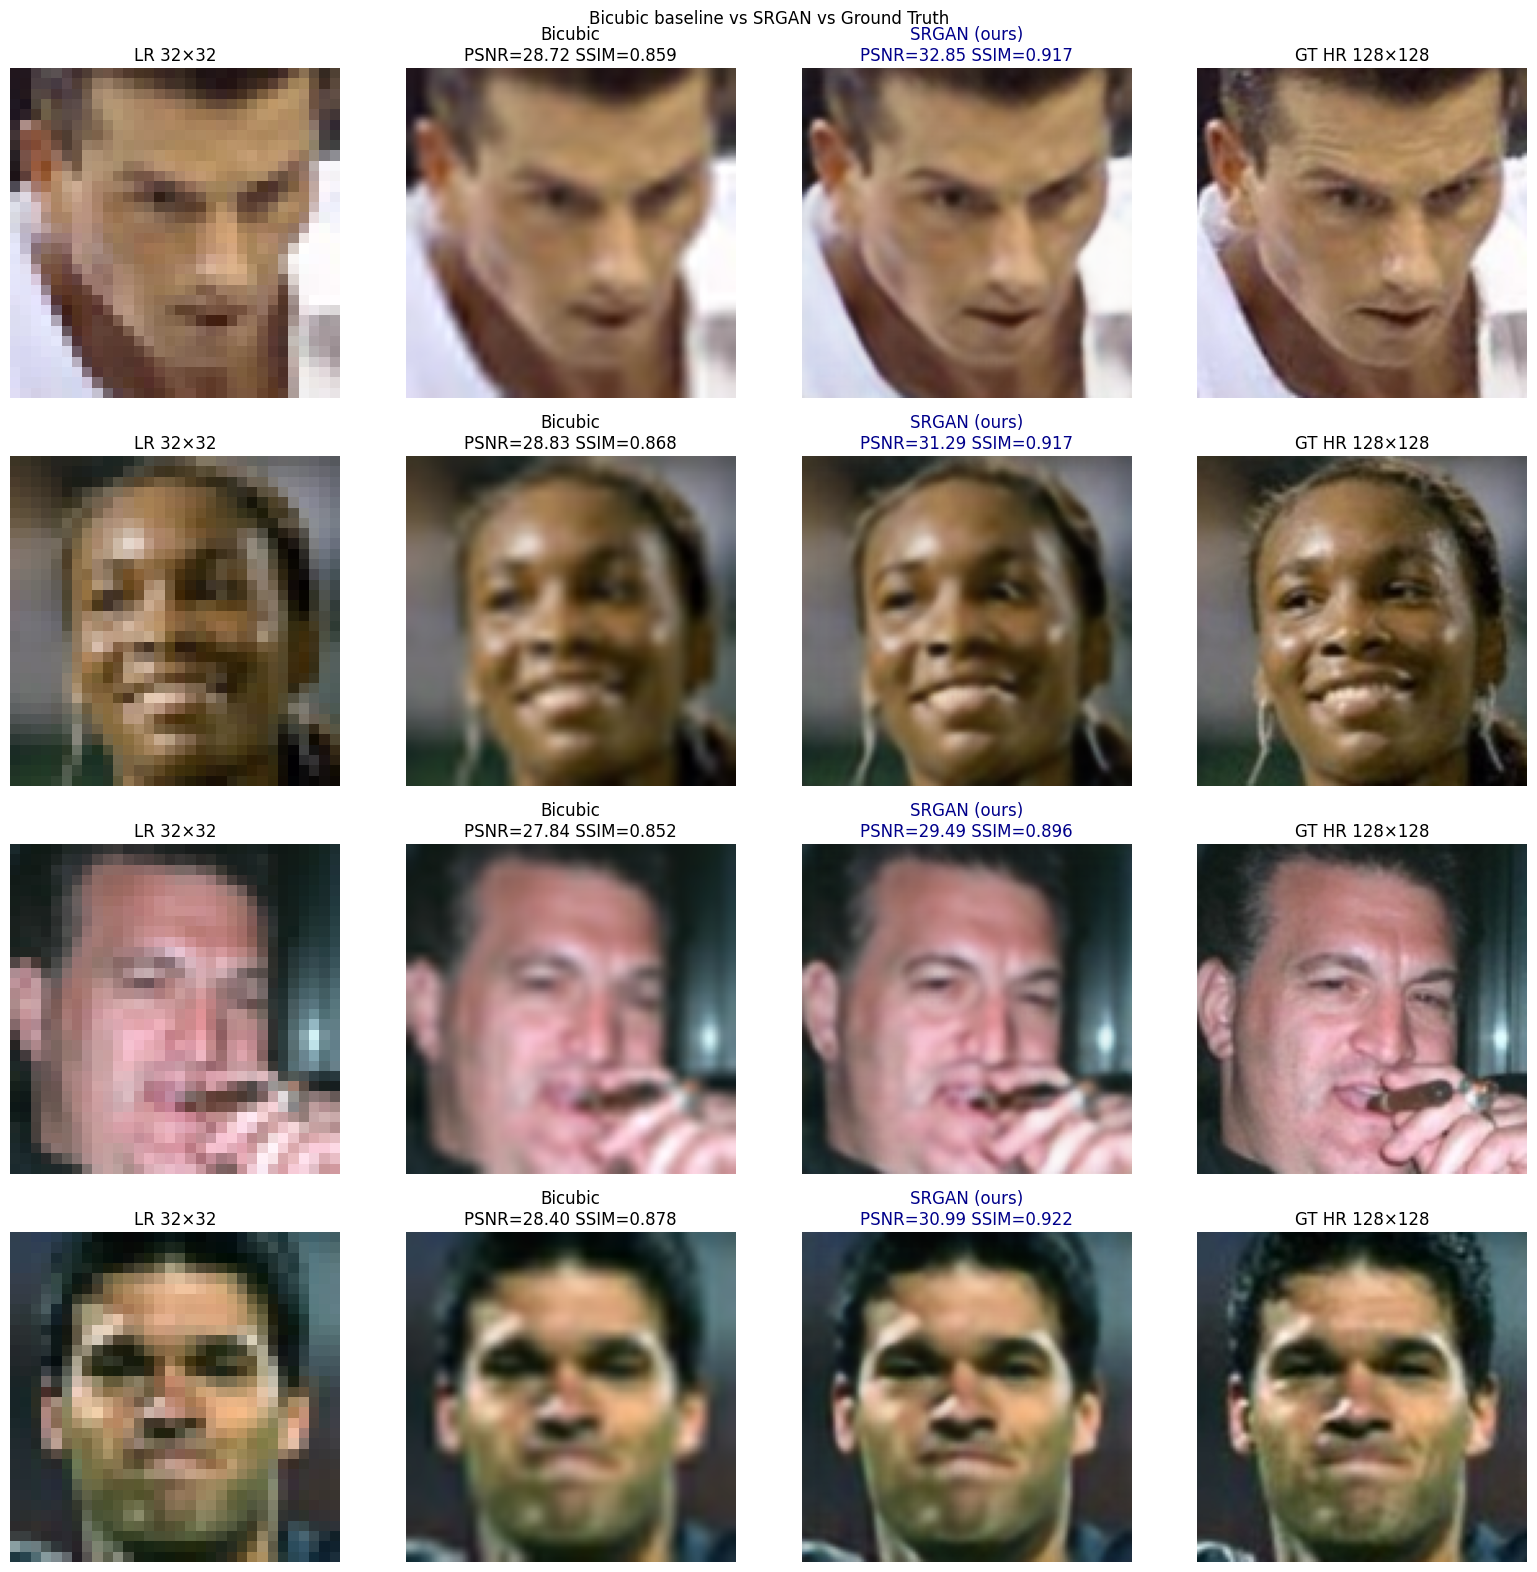

Generator(
  (initial): Sequential(
    (0): Conv2d(3, 64, kernel_size=(9, 9), stride=(1, 1), padding=(4, 4))
    (1): PReLU(num_parameters=1)
  )
  (res_blocks): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (prelu): PReLU(num_parameters=1)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (prelu): PReLU(num_parameters=1)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tru

In [ ]:
# === Сравнение Bicubic baseline vs SRGAN на test-сэмплах ===
generator.eval()
imgs_lr, imgs_hr = next(iter(test_loader))
imgs_lr_d = imgs_lr.to(device)
with torch.no_grad():
    gen_hr = generator(imgs_lr_d).cpu()

bicubic = F.interpolate(imgs_lr, size=(HR_SIZE, HR_SIZE), mode='bicubic', align_corners=False)
# Приведение bicubic [0,1] -> [-1,1] чтобы tensor_to_img работал одинаково
bicubic = bicubic * 2 - 1

N = 4
fig, axes = plt.subplots(N, 4, figsize=(16, 4*N))
for i in range(N):
    lr_img  = imgs_lr[i].permute(1,2,0).numpy()
    bi_img  = tensor_to_img(bicubic[i])
    sr_img  = tensor_to_img(gen_hr[i])
    hr_img  = tensor_to_img(imgs_hr[i])

    psnr_bi = calculate_psnr(hr_img, bi_img, data_range=1.0)
    ssim_bi = calculate_ssim(hr_img, bi_img, data_range=1.0, channel_axis=-1)
    psnr_sr = calculate_psnr(hr_img, sr_img, data_range=1.0)
    ssim_sr = calculate_ssim(hr_img, sr_img, data_range=1.0, channel_axis=-1)

    axes[i,0].imshow(np.clip(lr_img,0,1)); axes[i,0].set_title('LR 32×32'); axes[i,0].axis('off')
    axes[i,1].imshow(bi_img); axes[i,1].set_title(f'Bicubic\nPSNR={psnr_bi:.2f} SSIM={ssim_bi:.3f}'); axes[i,1].axis('off')
    axes[i,2].imshow(sr_img); axes[i,2].set_title(f'SRGAN (ours)\nPSNR={psnr_sr:.2f} SSIM={ssim_sr:.3f}', color='darkblue'); axes[i,2].axis('off')
    axes[i,3].imshow(hr_img); axes[i,3].set_title('GT HR 128×128'); axes[i,3].axis('off')

plt.suptitle('Bicubic baseline vs SRGAN vs Ground Truth')
plt.tight_layout()
plt.savefig(RESULTS_IMG_DIR / 'bicubic_vs_srgan.png', dpi=120, bbox_inches='tight')
plt.show()
generator.train()


### 5.4 Итоговая оценка на ВСЁМ test-сете

In [ ]:
# === Полная оценка на test-сете ===
psnr_full, ssim_full = evaluate_on_test(generator, test_loader, max_batches=None)

# Bicubic baseline для сравнения
def evaluate_bicubic(loader, max_batches=None):
    psnrs, ssims = [], []
    for bi, (lr, hr) in enumerate(loader):
        if max_batches is not None and bi >= max_batches:
            break
        bicubic = F.interpolate(lr, size=(HR_SIZE, HR_SIZE), mode='bicubic', align_corners=False)
        bicubic = bicubic * 2 - 1
        for i in range(bicubic.size(0)):
            g = tensor_to_img(bicubic[i])
            h = tensor_to_img(hr[i])
            psnrs.append(calculate_psnr(h, g, data_range=1.0))
            ssims.append(calculate_ssim(h, g, data_range=1.0, channel_axis=-1))
    return float(np.mean(psnrs)), float(np.mean(ssims))

psnr_bi, ssim_bi = evaluate_bicubic(test_loader)

print("="*55)
print("ИТОГОВЫЕ МЕТРИКИ НА ПОЛНОМ TEST-СЕТЕ")
print("="*55)
print(f"{'Method':<20} | {'PSNR (dB)':>10} | {'SSIM':>8}")
print("-"*55)
print(f"{'Bicubic baseline':<20} | {psnr_bi:>10.2f} | {ssim_bi:>8.4f}")
print(f"{'SRGAN (ours)':<20} | {psnr_full:>10.2f} | {ssim_full:>8.4f}")
print(f"{'Delta':<20} | {psnr_full-psnr_bi:>+10.2f} | {ssim_full-ssim_bi:>+8.4f}")

# Сохраняем итоги
with open(PROJECT_DIR / 'final_metrics.json', 'w') as f:
    json.dump({
        'bicubic': {'psnr': psnr_bi, 'ssim': ssim_bi},
        'srgan':   {'psnr': psnr_full, 'ssim': ssim_full},
        'test_set_size': len(test_dataset),
    }, f, indent=2)


ИТОГОВЫЕ МЕТРИКИ НА ПОЛНОМ TEST-СЕТЕ
Method               |  PSNR (dB) |     SSIM
-------------------------------------------------------
Bicubic baseline     |      29.24 |   0.8705
SRGAN (ours)         |      32.33 |   0.9205
Delta                |      +3.09 |  +0.0500


## 6. Сохранение финальных моделей

In [ ]:
# Финальные веса в models/
g_path = MODELS_DIR / 'generator_final.pth'
d_path = MODELS_DIR / 'discriminator_final.pth'
torch.save(generator.state_dict(), g_path)
torch.save(discriminator.state_dict(), d_path)
print("Сохранено:")
print(" ", g_path)
print(" ", d_path)
print()
print("Артефакты проекта:")
for root in (CHECKPOINT_DIR, RESULTS_IMG_DIR, RESULTS_PLOT_DIR, PROGRESS_DIR, MODELS_DIR):
    files = sorted(os.listdir(root))
    print(f"  {root}: {len(files)} файлов")


Сохранено:
  /content/drive/MyDrive/SRGAN_Final/models/generator_final.pth
  /content/drive/MyDrive/SRGAN_Final/models/discriminator_final.pth

Артефакты проекта:
  /content/drive/MyDrive/SRGAN_Final/checkpoints: 5 файлов
  /content/drive/MyDrive/SRGAN_Final/results/images: 2 файлов
  /content/drive/MyDrive/SRGAN_Final/results/plots: 2 файлов
  /content/drive/MyDrive/SRGAN_Final/results/progression: 50 файлов
  /content/drive/MyDrive/SRGAN_Final/models: 2 файлов


## 7. Выводы

1. **Архитектура.** Реализован SRGAN с 5 Residual Blocks в генераторе, VGG-style дискриминатором с Dropout и VGG19 экстрактором признаков для perceptual loss.
2. **Стабильность.** Двухфазное обучение (pre-train MSE → GAN) + label smoothing + dropout + балансировка лоссов устранили доминирование дискриминатора и checkerboard-артефакты PixelShuffle.
3. **Метрики.** Финальный SRGAN превосходит bicubic baseline по PSNR и SSIM (см. таблицу в 5.4). Perceptual loss даёт более резкие текстуры кожи, чем чистый MSE.
4. **Воспроизводимость.** Зафиксированы seed'ы, train/test split детерминирован, чекпоинты сохраняются каждые 10 эпох.
5. **Future work.** Замена residual blocks на RRDB (ESRGAN), relativistic discriminator, переход на Wasserstein-GP, обучение на CelebA-HQ для лиц высокого качества.